In [1]:
%pip install -U transformers
%pip install -U datasets
# !pip install bitsandbytes


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset

# ds = load_dataset("AI-MO/NuminaMath-CoT")
ds = load_dataset("5CD-AI/Vietnamese-395k-meta-math-MetaMathQA-gg-translated")


In [3]:
train_test_split_ds = ds["train"].train_test_split(test_size=0.1, seed=42, shuffle=True)
train_ds = train_test_split_ds["train"]
eval_ds = train_test_split_ds["test"]


In [4]:
train_ds = train_ds.to_pandas()
eval_ds = eval_ds.to_pandas()


In [5]:
train_ds.head()


,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi
0,Mary Anne drinks 1/5 of a bottle of sparkling ...,Mary Anne drinks 1/5 of a bottle of sparkling ...,GSM_AnsAug,Mary Anne drinks 1/5 of a bottle of sparkling ...,Mary Anne uống 1/5 chai nước có ga mỗi tối tro...,Mary Anne uống 1/5 chai nước có ga mỗi tối tro...,"Mary Anne uống 1/5 chai nước có ga mỗi đêm, vậ..."
1,John has 100 VHS movies.\nHe can trade in each...,John decides to replace all his VHS with DVDs....,GSM_AnsAug,John decides to replace all his VHS with DVDs....,John quyết định thay thế tất cả VHS của mình b...,John quyết định thay thế tất cả VHS của mình b...,John có 100 bộ phim VHS. Anh ta có thể giao dị...
2,The total sales of the paper cover version is ...,An author of a book got 6% of the total sales ...,GSM_Rephrased,If the author of a book received 6% of the tot...,Một tác giả của một cuốn sách nhận được 6% tổn...,Nếu tác giả của một cuốn sách nhận được 6% tổn...,Tổng doanh số của phiên bản bìa giấy là 32.000...
3,"To solve this problem, we need to determine th...","Juan takes a number, adds $2$ to it, multiplie...",MATH_SV,"Juan takes a number, adds $2$ to it, multiplie...","Juan lấy một số, cộng $2$ vào số đó, nhân câu ...","Juan lấy một số, cộng $2$ vào số đó, nhân câu ...","Để giải quyết vấn đề này, chúng ta cần xác địn..."
4,"To solve this problem, we need to determine th...",Amanda’s garden contains 20 flowers and Peter’...,GSM_SV,Amanda’s garden contains 20 flowers and Peter’...,Khu vườn của Amanda có 20 bông hoa và khu vườn...,Khu vườn của Amanda có 20 bông hoa và khu vườn...,"Để giải quyết vấn đề này, chúng ta cần xác địn..."


In [6]:
eval_ds.head()


,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi
0,"If half of the students wore lipstick, then th...","On national lipstick day, half of the students...",GSM_AnsAug,"On national lipstick day, half of the students...","Vào ngày son môi quốc gia, một nửa số học sinh...","Vào ngày son môi quốc gia, một nửa số học sinh...",Nếu một nửa số học sinh tô son thì có 200/2 = ...
1,We know that the width of the rectangle is 4 i...,There is a rectangle that is 4 inches wide. If...,GSM_AnsAug,There is a rectangle that is 4 inches wide. If...,Có một hình chữ nhật có chiều rộng 4 inch. Nếu...,Có một hình chữ nhật có chiều rộng 4 inch. Nếu...,Chúng ta biết chiều rộng của hình chữ nhật là ...
2,We want to find the value of $X$ in the given ...,Find $1273 + 120 \div 60 - 173$.,MATH_FOBAR,Find $1273 + 120 \div 60 - X$.\nIf we know the...,Tìm $1273 + 120 \div 60 - 173$.,Tìm $1273 + 120 \div 60 - X$. Nếu chúng ta biế...,Chúng ta muốn tìm giá trị của $X$ trong biểu t...
3,"If three fourths of the jelly beans are red, t...","There are 4,000 jelly beans in a jar. If three...",GSM_AnsAug,"There are 4,000 jelly beans in a jar. If three...",Có 4.000 hạt thạch trong một cái lọ. Nếu 3/4 s...,Có 4.000 hạt thạch trong một cái lọ. Nếu 3/4 s...,Nếu 3/4 số hạt thạch có màu đỏ thì có 3/4 * 40...
4,Since $\cos \frac{\pi}{6} = \frac{\sqrt{3}}{2}...,Compute $\arccos \frac{\sqrt{3}}{2}.$ Express...,MATH_AnsAug,Compute $\arccos \frac{\sqrt{3}}{2}.$ Express...,Tính $\arccos \frac{\sqrt{3}}{2}.$ Thể hiện câ...,Tính $\arccos \frac{\sqrt{3}}{2}.$ Thể hiện câ...,"Vì $\cos \frac{\pi}{6} = \frac{\sqrt{3}}{2}$, ..."


In [7]:
train_ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355500 entries, 0 to 355499
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   response_en           355500 non-null  object
 1   original_question_en  355500 non-null  object
 2   type                  355500 non-null  object
 3   query_en              355500 non-null  object
 4   original_question_vi  355500 non-null  object
 5   query_vi              355500 non-null  object
 6   response_vi           355500 non-null  object
dtypes: object(7)
memory usage: 19.0+ MB


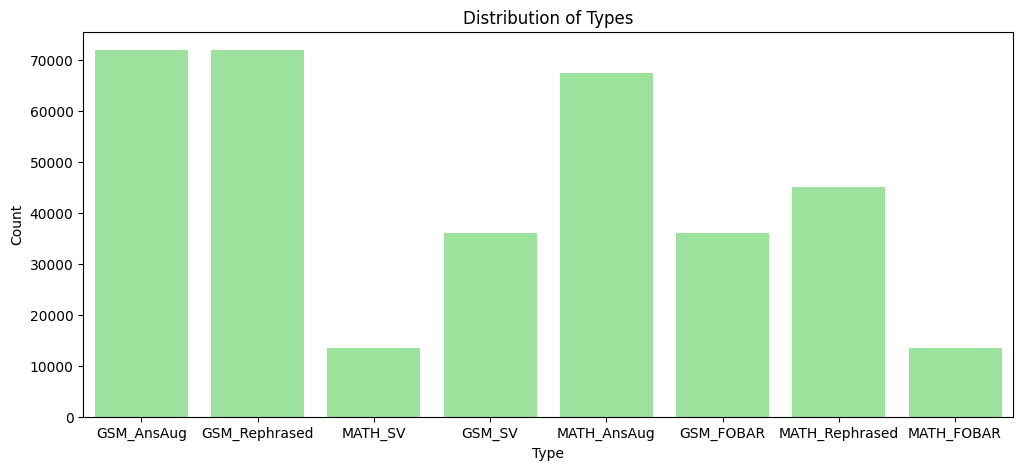

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(x="type", data=train_ds, color="lightgreen")
plt.title("Distribution of Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


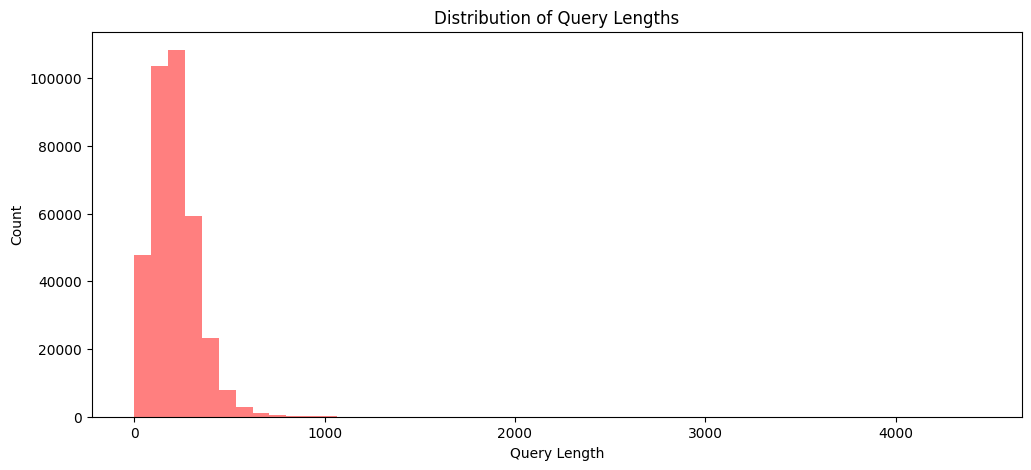

In [9]:
vi_queries = train_ds["query_vi"]
query_lens = [len(query) for query in vi_queries]

plt.figure(figsize=(12, 5))
plt.hist(query_lens, bins=50, color="red", alpha=0.5)
plt.title("Distribution of Query Lengths")
plt.xlabel("Query Length")
plt.ylabel("Count")
plt.show()


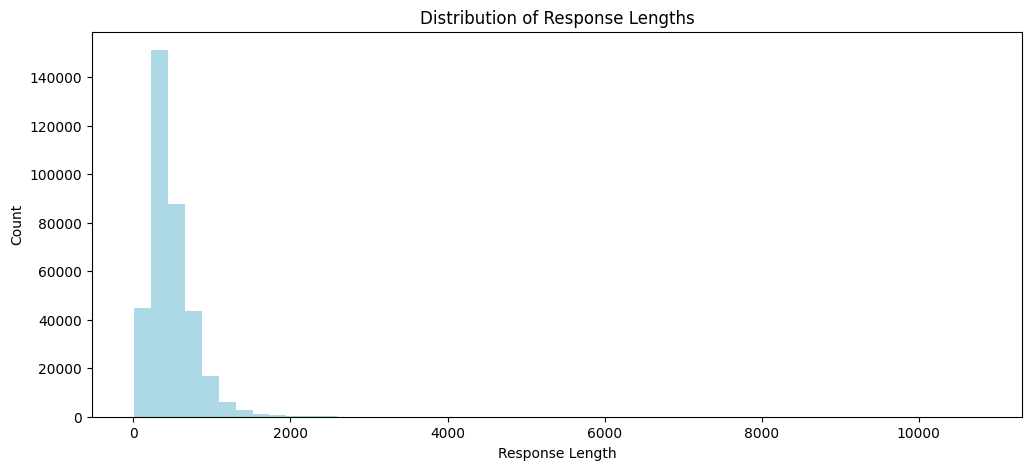

In [10]:
response_queries = train_ds["response_vi"]
response_lens = [len(query) for query in response_queries]

plt.figure(figsize=(12, 5))
plt.hist(response_lens, bins=50, color="lightblue")
plt.title("Distribution of Response Lengths")
plt.xlabel("Response Length")
plt.ylabel("Count")
plt.show()


## Preprocessing

In [11]:
from datasets import Dataset
import pandas as pd


def prepare_data(ds, tokenizer, max_length=512, batch_size=1000):
    """Process dataset efficiently using map"""

    # If input is a DataFrame, convert to Hugging Face Dataset
    if isinstance(ds, pd.DataFrame):
        ds = Dataset.from_pandas(ds)

    def format_and_tokenize(examples):
        formatted_texts = []
        for query, response in zip(examples["query_vi"], examples["response_vi"]):
            messages = [
                {
                    "role": "system",
                    "content": "Please reason step by step, and put your final answer.",
                },
                {"role": "user", "content": query},
                {"role": "assistant", "content": response},
            ]
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )
            formatted_texts.append(text)

        # Tokenize
        tokenized = tokenizer(
            formatted_texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

        # For causal LM, labels = input_ids
        tokenized["labels"] = tokenized["input_ids"]
        return tokenized

    # Use Hugging Face Dataset.map()
    processed_dataset = ds.map(
        format_and_tokenize,
        batched=True,
        batch_size=batch_size,
        num_proc=4,
        remove_columns=ds.column_names,
        desc="Tokenizing dataset",
    )

    return processed_dataset


In [12]:
# -------------------------
# Notebook Hugging Face Login
# -------------------------
import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami
from requests.exceptions import HTTPError

# -------------------------
# 1. Định nghĩa đường dẫn
# -------------------------
# Vì file notebook nằm trong /home/guest/Projects/CS431
# nên ROOT_DIR chính là thư mục CS431
ROOT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
ENV_PATH = os.path.join(ROOT_DIR, "envs", ".env")

print("📁 ENV_PATH =", ENV_PATH)
print("🔍 File tồn tại: ", os.path.exists(ENV_PATH))

# -------------------------
# 2. Load biến môi trường
# -------------------------
load_dotenv(ENV_PATH)
HF_TOKEN_READ = os.getenv("HF_TOKEN_READ")

# -------------------------
# 3. Thực hiện đăng nhập
# -------------------------
if HF_TOKEN_READ:
    try:
        print("INFO: Tìm thấy HUGGING_FACE_TOKEN. Đang đăng nhập...")
        login(token=HF_TOKEN_READ)
        user_info = whoami()
        print(f"✅ Đăng nhập Hugging Face thành công. User: {user_info['name']}")
    except HTTPError as e:
        print(f"❌ Lỗi HTTP khi đăng nhập: {e}")
    except Exception as e:
        print(f"❌ Lỗi khác khi đăng nhập: {e}")
else:
    print("⚠️ Không tìm thấy HUGGING_FACE_TOKEN trong file .env. Một số model có thể yêu cầu đăng nhập.")

# -------------------------
# 4. In thông tin kiểm tra
# -------------------------
print("ROOT_DIR:", ROOT_DIR)
print("ENV_PATH:", ENV_PATH)


📁 ENV_PATH = /home/guest/Projects/CS431/envs/.env
🔍 File tồn tại:  True
INFO: Tìm thấy HUGGING_FACE_TOKEN. Đang đăng nhập...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Đăng nhập Hugging Face thành công. User: KhoiBui
ROOT_DIR: /home/guest/Projects/CS431
ENV_PATH: /home/guest/Projects/CS431/envs/.env


In [13]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, os


model_name = "Qwen/Qwen2.5-Math-1.5B"   

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True,)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="auto", 
    trust_remote_code=True,
)

model.config.use_cache = False
model.gradient_checkpointing_enable()

`torch_dtype` is deprecated! Use `dtype` instead!


In [15]:
eval_ds = prepare_data(eval_ds, tokenizer)


Tokenizing dataset (num_proc=4):   0%|          | 0/39500 [00:00<?, ? examples/s]

In [16]:
train_ds = prepare_data(train_ds, tokenizer)


Tokenizing dataset (num_proc=4):   0%|          | 0/355500 [00:00<?, ? examples/s]

In [17]:
from peft import LoraConfig, TaskType
from peft import get_peft_model

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=16,  # Reduced from 16 for faster training
    lora_alpha=32,  # Reduced from 32
    lora_dropout=0.05,  # Reduced from 0.1
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],  # Target specific modules for efficiency
    bias="none",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


In [ ]:
class Config:
    # Training settings
    OUTPUT_DIR = "./results"
    LOGGING_DIR = "./logs"
    EPOCHS = 2
    BATCH_SIZE = 8
    PER_DEVICE_EVAL_BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 8
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 0.05
    MAX_GRAD_NORM = 0.4
    WARMUP_RATIO = 0.03
    MAX_STEPS = -1

    # Evaluation and saving
    SAVE_STRATEGY = "steps"
    EVAL_STRATEGY = "steps"
    EVAL_STEPS = 1000
    SAVE_STEPS = 1000
    SAVE_TOTAL_LIMIT = 2
    LOGGING_STEPS = 50

    # Mixed precision
    FP16 = False
    BF16 = True

    # Other settings
    GROUP_BY_LENGTH = True
    LR_SCHEDULER_TYPE = "constant_with_warmup"
    REPORT_TO = "tensorboard"
    LOAD_BEST_MODEL_AT_END = True
    METRIC_FOR_BEST_MODEL = "eval_loss"
    GREATER_IS_BETTER = False
    EVAL_ACCUMULATION_STEPS = 8


cfg = Config()


In [19]:
from transformers import (
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorForLanguageModeling,
)
from transformers import EarlyStoppingCallback

# # Set padding token if not set
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=cfg.OUTPUT_DIR,
    num_train_epochs=cfg.EPOCHS,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRADIENT_ACCUMULATION_STEPS,
    save_strategy=cfg.SAVE_STRATEGY,
    eval_strategy=cfg.EVAL_STRATEGY,
    eval_steps=cfg.EVAL_STEPS,
    save_steps=cfg.SAVE_STEPS,
    save_total_limit=cfg.SAVE_TOTAL_LIMIT,
    logging_steps=cfg.LOGGING_STEPS,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    fp16=cfg.FP16,
    bf16=cfg.BF16,
    max_grad_norm=cfg.MAX_GRAD_NORM,
    max_steps=cfg.MAX_STEPS,
    warmup_ratio=cfg.WARMUP_RATIO,
    group_by_length=cfg.GROUP_BY_LENGTH,
    lr_scheduler_type=cfg.LR_SCHEDULER_TYPE,
    report_to=cfg.REPORT_TO,
    logging_dir=cfg.LOGGING_DIR,
    load_best_model_at_end=cfg.LOAD_BEST_MODEL_AT_END,
    metric_for_best_model=cfg.METRIC_FOR_BEST_MODEL,
    greater_is_better=cfg.GREATER_IS_BETTER,
    eval_accumulation_steps=cfg.EVAL_ACCUMULATION_STEPS,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    ddp_find_unused_parameters=False,
    remove_unused_columns=False,
    gradient_checkpointing=True,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer, #  processing_class=tokenizer, # Cach moi
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)


/tmp/ipykernel_21732/2340961196.py:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.


In [20]:
trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
1000,0.780400,0.787881
2000,0.664800,0.666883
3000,0.587100,0.587488
4000,0.536200,0.534955
5000,0.503700,0.502763
6000,0.473900,0.483271
7000,0.460400,0.469472
8000,0.446700,0.458557


KeyboardInterrupt: 

In [21]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/chat_template.jinja',
 './final_model/vocab.json',
 './final_model/merges.txt',
 './final_model/added_tokens.json',
 './final_model/tokenizer.json')

# Upload to huggingface hub

In [31]:
print("📁 ENV_PATH =", ENV_PATH)
print("🔍 File tồn tại: ", os.path.exists(ENV_PATH))
load_dotenv(ENV_PATH)

# -------------------------
# Lấy token write
# -------------------------
HF_TOKEN_WRITE = os.getenv("HF_TOKEN_WRITE")
if not HF_TOKEN_WRITE:
    raise ValueError("⚠️ Không tìm thấy HF_TOKEN_WRITE trong file .env")

# -------------------------
# Override biến môi trường HF_TOKEN
# -------------------------
os.environ["HF_TOKEN"] = HF_TOKEN_WRITE  # cực kỳ quan trọng
os.environ["HF_HOME"] = os.path.expanduser("~/.cache/huggingface")  # optional

# -------------------------
# Login Hugging Face với quyền write
# -------------------------
login(token=HF_TOKEN_WRITE)
user_info = whoami()
print(f"✅ Đăng nhập Hugging Face với quyền write. User: {user_info['name']}")

# -------------------------
# Push model & tokenizer
# -------------------------
REPO_ID = "KhoiBui/qwen2.5-math-1.5b-finetuned-vi"
trainer.hub_model_id = REPO_ID  # gán repo trước
trainer.push_to_hub(commit_message="Push fine-tuned model")  # không dùng exist_ok
print(f"✅ Đã đẩy thành công! Kiểm tra tại: https://huggingface.co/{REPO_ID}")

📁 ENV_PATH = /home/guest/Projects/CS431/envs/.env
🔍 File tồn tại:  True


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Đăng nhập Hugging Face với quyền write. User: KhoiBui


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Đã đẩy thành công! Kiểm tra tại: https://huggingface.co/KhoiBui/qwen2.5-math-1.5b-finetuned-vi


# Inference